# Lecture 9 — why the signed sum of errors is not a loss

Page 8 of the notes defines `error = predicted − expected` and scores the model two ways:

- **L2** = Σ error² = 9
- **"L1"** = Σ error (no absolute value) = −5

This notebook shows why Σ error is a broken thing to minimise, what the fix is,
and what the fixed L1 gives you that L2 does not.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def signed_sum(e): return e.sum()          # the notes' "L1"  (no absolute value)
def L1(e):         return np.abs(e).sum()  # the fix
def L2(e):         return (e ** 2).sum()   # the notes' L2

expected  = np.array([5, 6, 8, 10])
predicted = np.array([3, 6, 6,  9])
error = predicted - expected

print("error      :", error)
print("signed sum :", signed_sum(error), "  (notes: -5)")
print("L2         :", L2(error),         "  (notes: 9)")
print("L1 fixed   :", L1(error))

error      : [-2  0 -2 -1]
signed sum : -5   (notes: -5)
L2         : 9   (notes: 9)
L1 fixed   : 5


## Problem 1 — the signed sum has no floor

If smaller is better, what is the best possible value? Compare a few error columns.

In [2]:
def show(columns):
    for name, e in columns.items():
        e = np.array(e)
        print(f"{name:16s} {str(e.tolist()):22s} signed sum = {signed_sum(e):6}    L1 = {L1(e):5}    L2 = {L2(e):8}")

show({
    "notes":          [-2, 0, -2, -1],
    "perfect fit":    [ 0, 0,  0,  0],
    "one huge miss":  [-1000, 0, 0, 0],
})

notes            [-2, 0, -2, -1]        signed sum =     -5    L1 =     5    L2 =        9
perfect fit      [0, 0, 0, 0]           signed sum =      0    L1 =     0    L2 =        0
one huge miss    [-1000, 0, 0, 0]       signed sum =  -1000    L1 =  1000    L2 =  1000000


The column with a single miss of 1000 scores **−1000**, which "beats" the notes' −5.
A **perfect fit** scores 0, which is *worse* than −5.
Nothing stops the score from heading to −∞. There is no best value to find.

## Problem 2 — errors cancel

Even if we ignore the missing floor, positive and negative errors net out.

In [3]:
show({
    "notes":           [-2, 0, -2, -1],
    "cancel (small)":  [-100,   95, 0, 0],
    "cancel (huge)":   [1000, -1005, 0, 0],
    "cancel to zero":  [100,  -100, 0, 0],
})

notes            [-2, 0, -2, -1]        signed sum =     -5    L1 =     5    L2 =        9
cancel (small)   [-100, 95, 0, 0]       signed sum =     -5    L1 =   195    L2 =    19025
cancel (huge)    [1000, -1005, 0, 0]    signed sum =     -5    L1 =  2005    L2 =  2010025
cancel to zero   [100, -100, 0, 0]      signed sum =      0    L1 =   200    L2 =    20000


Three of these score exactly **−5** or **0** while containing misses of 100 to 1005.
So "signed sum near its best value" says nothing about any individual error.

## See it — a model that predicts one constant `c` for everything

Sweep `c` and plot each loss as a function of `c`.

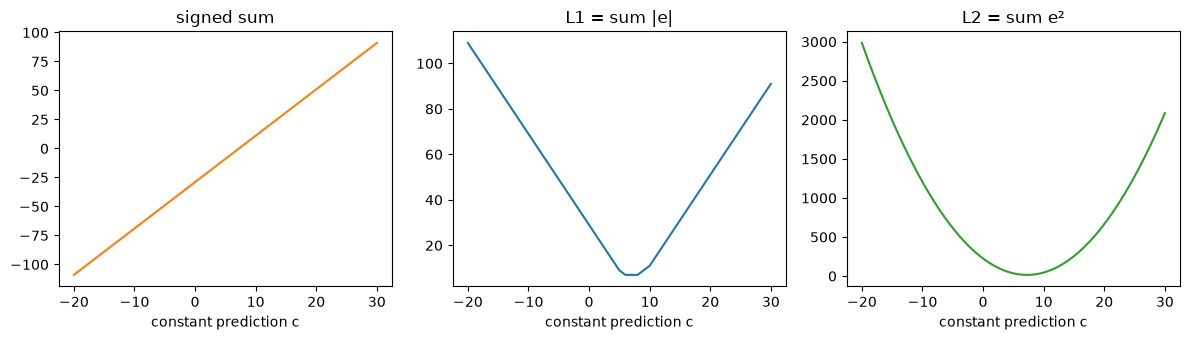

In [4]:
c = np.linspace(-20, 30, 500)
losses = [("signed sum", signed_sum, "tab:orange"), ("L1 = sum |e|", L1, "tab:blue"), ("L2 = sum e²", L2, "tab:green")]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (name, f, colour) in zip(axes, losses):
    ax.plot(c, [f(ci - expected) for ci in c], color=colour)
    ax.set_title(name)
    ax.set_xlabel("constant prediction c")
plt.tight_layout()
plt.show()

- **Signed sum**: a straight line. No bottom.
- **L1**: V-shaped, bottom is flat from 6 to 8 — the median of (5, 6, 8, 10).
- **L2**: a parabola, bottom at 7.25 — the mean of (5, 6, 8, 10).

## The fix — absolute value

$$\text{L1} = \sum |\,\text{predicted} - \text{expected}\,|$$

On the notes' column: 2 + 0 + 2 + 1 = **5**. Every term is now ≥ 0, the sum is 0 only when
every prediction is exact, and cancellation is impossible.

## What L1 gives you that L2 does not — robustness to an outlier

Replace the 10 with 1000 (one corrupted label) and find the best constant under each loss.

In [5]:
def best_constant(targets, f):
    c = np.linspace(-50, 1100, 23001)
    loss = np.array([f(ci - targets) for ci in c])
    winners = c[np.isclose(loss, loss.min(), rtol=0, atol=1e-9)]    # all c that tie for the minimum
    return winners.min(), winners.max()

for targets in [np.array([5, 6, 8, 10]), np.array([5, 6, 8, 1000])]:
    lo2, hi2 = best_constant(targets, L2)
    lo1, hi1 = best_constant(targets, L1)
    print(f"targets {str(targets.tolist()):18s}  L2 best c = {lo2:7.2f}            (mean   = {targets.mean():.2f})")
    print(f"{'':27s}L1 best c = {lo1:5.2f} to {hi1:5.2f}   (median = {np.median(targets):.2f})")

targets [5, 6, 8, 10]       L2 best c =    7.25            (mean   = 7.25)
                           L1 best c =  6.00 to  8.00   (median = 7.00)


targets [5, 6, 8, 1000]     L2 best c =  254.75            (mean   = 254.75)
                           L1 best c =  6.00 to  8.00   (median = 7.00)


One corrupted label dragged L2's answer from 7.25 to 254.75. L1's answer did not move.

**One sentence:** L1 penalises each error linearly instead of quadratically, so a single outlier
cannot dominate the fit — its minimiser is the median, where L2's is the mean.

## Bonus 1 — the same thing on a real regression line

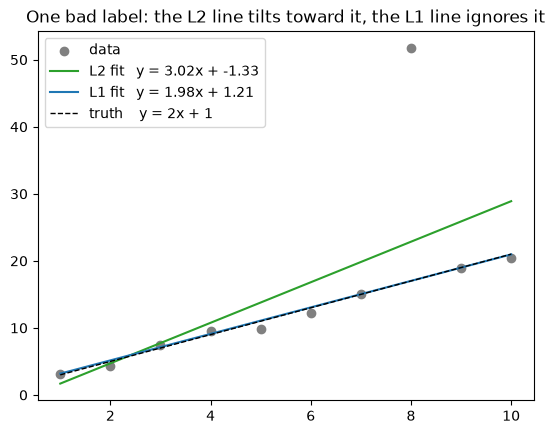

In [6]:
from scipy.optimize import minimize

x = np.arange(1, 11)
y = 2 * x + 1 + np.random.default_rng(42).normal(0, 0.6, 10)
y[7] += 35                                                   # one corrupted label

a2, b2 = np.polyfit(x, y, 1)                                 # L2: closed form
a1, b1 = minimize(lambda p: np.abs(y - (p[0] * x + p[1])).sum(), x0=[a2, b2], method="Nelder-Mead").x   # L1: numerical

plt.scatter(x, y, color="gray", label="data")
plt.plot(x, a2 * x + b2, color="tab:green", label=f"L2 fit   y = {a2:.2f}x + {b2:.2f}")
plt.plot(x, a1 * x + b1, color="tab:blue",  label=f"L1 fit   y = {a1:.2f}x + {b1:.2f}")
plt.plot(x, 2 * x + 1, "k--", lw=1,        label="truth    y = 2x + 1")
plt.legend()
plt.title("One bad label: the L2 line tilts toward it, the L1 line ignores it")
plt.show()

## Bonus 2 — what the signed sum actually *is*

$$\frac{d}{dc}\sum (c - y_i)^2 = 2 \sum (c - y_i)$$

The notes' "L1" is the **derivative of L2**. Setting it to zero is how least squares finds the mean.
Minimising it is a category error. In the plot above, the orange line crosses zero exactly where the
green parabola bottoms out.

In [7]:
c = np.linspace(-5, 20, 1001)
l2 = np.array([L2(ci - expected) for ci in c])
s  = np.array([signed_sum(ci - expected) for ci in c])
print("max |dL2/dc − 2·signed_sum| :", np.abs(np.gradient(l2, c) - 2 * s)[1:-1].max().round(8))

max |dL2/dc − 2·signed_sum| : 0.0


## Summary

1. **Why it is broken:** Σ error is not a distance — it has no floor and it cancels, so its value says nothing about individual errors.
2. **Columns that score ≤ −5 while fitting far worse:** (−1000, 0, 0, 0) → −1000; (−100, +95, 0, 0) → −5; (+1000, −1005, 0, 0) → −5; (+100, −100, 0, 0) → 0.
3. **Minimal fix:** absolute-value bars, Σ |error|.
4. **What fixed L1 gives that L2 does not:** a linear penalty, so one outlier cannot dominate; the minimiser is the median instead of the mean.